In [ ]:
"""Plot squeeze experiments of an institution."""

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [16]:
import pathlib as pl
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import sys
import os
sys.path.append(os.path.abspath('src'))

In [4]:
from smc_benchmark.read import read
from smc_benchmark._naming import FORCE, GAP
from smc_benchmark.manipulate import crop_to_range, mean_std, print_data_structure

In [5]:
institution = "uob"
#folder = pl.Path("F:/C-SMC_Benchmark/IVW/IVW_Press_Force_Data")
folder = pl.Path(r"tests/data/uob/force-disp-data_trimmed/")

In [9]:
# Read experimental data
data = read(institution, folder)
print_data_structure(data)

tests/data/uob/force-disp-data_trimmed
📁 Total number of uob data files: 95
Material CF5012K file number 24 is not in CONFIG_TO_NUMBER_
Material CF6012K file number 24 is not in CONFIG_TO_NUMBER_
Material CF4012K file number 24 is not in CONFIG_TO_NUMBER_
Material CF5050K file number 24 is not in CONFIG_TO_NUMBER_
Material CF503K file number 24 is not in CONFIG_TO_NUMBER_
... loaded 90 uob data files.
Material: CF503K
|-- Experiment: 5mm 50x50 (samples: 6)
|-- Experiment: 3mm 50x50 (samples: 6)
|-- Experiment: 7mm 50x50 (samples: 6)
Material: CF5012K
|-- Experiment: 3mm 50x50 (samples: 6)
|-- Experiment: 7mm 50x50 (samples: 6)
|-- Experiment: 5mm 50x50 (samples: 6)
Material: CF5050K
|-- Experiment: 5mm 50x50 (samples: 6)
|-- Experiment: 7mm 50x50 (samples: 6)
|-- Experiment: 3mm 50x50 (samples: 6)
Material: CF4012K
|-- Experiment: 5mm 50x50 (samples: 6)
|-- Experiment: 3mm 50x50 (samples: 6)
|-- Experiment: 7mm 50x50 (samples: 6)
Material: CF6012K
|-- Experiment: 3mm 50x50 (samples: 6)

In [14]:
x_name = GAP
y_name = FORCE
max_gap = 11.0
min_gap_map = {"7mm": 7.0, "5mm": 5.0, "3mm": 3.0}
min_gap_wildcard = 3.0

x_name = GAP
y_name = FORCE
max_gap = 11.0
min_gap_map = {"7mm": 7.0, "5mm": 5.0, "3mm": 3.0}
min_gap_wildcard = 3.0

plot_samples = False
plot_mean_std = True
show_std_legend = False

In [18]:
# Styles for individual 100x100 plots
config_styles = {
    "3mm": {"color": "blue", "marker": "+"},
    "5mm": {"color": "red", "marker": "D"},
    "7mm": {"color": "green", "marker": "o"},
}


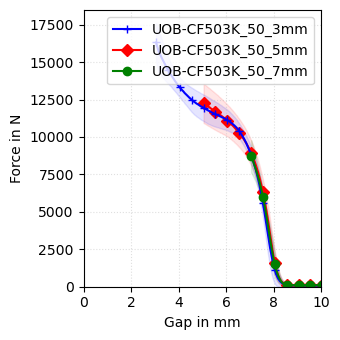

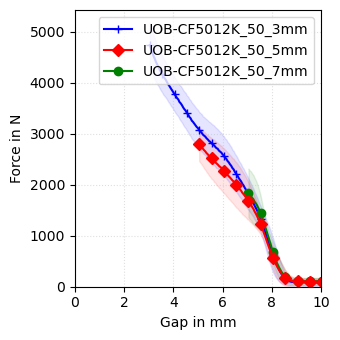

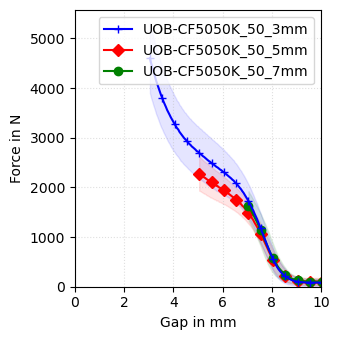

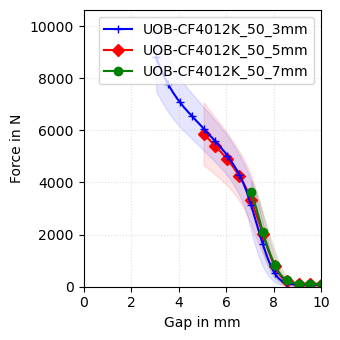

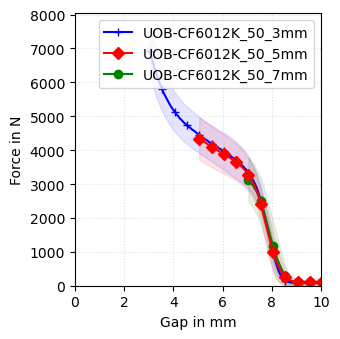

In [24]:
# ---------------------------------
# Per-material plots at 50x50
# ---------------------------------
for material, configs in data.items():
    fig, ax = plt.subplots()
    fig.set_size_inches(3.5, 3.5)
    y_max = 0

    for config, experiments in configs.items():
        if "50x50" not in config or not any(mm in config for mm in ["3mm", "5mm", "7mm"]):
            continue

        min_gap = next((v for k, v in min_gap_map.items() if k in config), min_gap_wildcard)
        experiments_cropped = crop_to_range(experiments, min_gap, max_gap, x_name, True)

        x_interp, y_mean, y_std = mean_std(experiments_cropped, x_name, y_name)
        mask = y_mean >= 0
        x_interp_filtered = x_interp[mask]
        y_mean_filtered = y_mean[mask]
        y_std_filtered = y_std[mask]

        if len(x_interp_filtered) == 0:
            continue

        style_key = next((k for k in config_styles if k in config), None)
        if style_key is None:
            continue
        style = config_styles[style_key]

        label = f"{institution.upper()}-{material}_50_{style_key}"

        ax.fill_between(
            x_interp_filtered,
            y_mean_filtered - y_std_filtered,
            y_mean_filtered + y_std_filtered,
            color=style["color"],
            alpha=0.1,
            label=f"{label} Std" if show_std_legend else "_nolegend_"
        )
        ax.plot(
            x_interp_filtered,
            y_mean_filtered,
            label=label,
            color=style["color"],
            marker=style["marker"],
            markevery=10
        )
        y_max = max(y_max, np.max(y_mean_filtered + y_std_filtered))

    ax.set_xlabel("Gap in mm")
    ax.set_ylabel("Force in N")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1)

    desired_order = [
        f"{institution.upper()}-{material}_50_3mm",
        f"{institution.upper()}-{material}_50_5mm",
        f"{institution.upper()}-{material}_50_7mm"
    ]
    if show_std_legend:
        desired_order = [item for x in desired_order for item in (x, f"{x} Std")]

    handles, labels = ax.get_legend_handles_labels()
    label_map = dict(zip(labels, handles))
    ordered_handles = [label_map[l] for l in desired_order if l in label_map]
    if ordered_handles:
        ax.legend(handles=ordered_handles)

    plt.grid(linestyle=":", alpha=0.5, color="silver")
    plt.tight_layout()
    plt.savefig(f"{institution.upper()}-{material}_50.png", dpi=900)
    plt.show()

In [20]:
# ---------------------------------
# Comparison plots for all materials
# ---------------------------------

# Material style mapping
material_style_map = {
    "CF503K":  {"color": "blue",  "marker": "+"},
    "CF5012K": {"color": "red",   "marker": "D"},
    "CF5050K": {"color": "green", "marker": "o"},
    "CF6012K": {"color": "y",     "marker": "s"},
    "CF4012K": {"color": "m",     "marker": "+"},
}

materials_order = ["CF503K", "CF5012K", "CF5050K", "CF6012K", "CF4012K"]

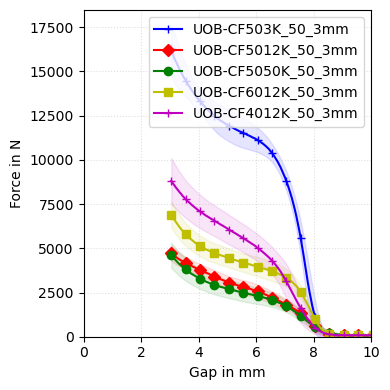

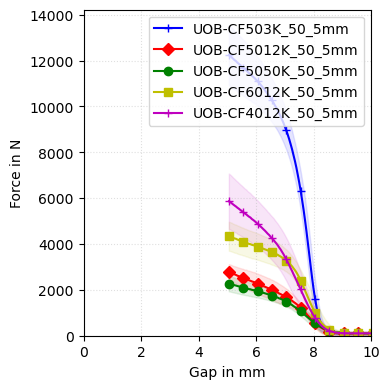

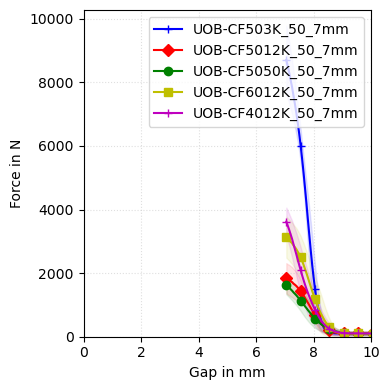

In [23]:
#for size in ["100x100", "50x50"]:
for size in ["50x50"]:
    specimen_size = size.split("x")[0]  # "100" or "50"

    for thickness in ["3mm", "5mm", "7mm"]:
        fig, ax = plt.subplots()
        fig.set_size_inches(4, 4)
        y_max = 0

        for material in materials_order:
            if material not in data:
                continue

            configs = data[material]
            style = material_style_map.get(material, {"color": "black", "marker": "."})

            matching_configs = [cfg for cfg in configs if size in cfg and thickness in cfg]
            if not matching_configs:
                continue

            for config in matching_configs:
                experiments = configs[config]

                min_gap = next((v for k, v in min_gap_map.items() if k in config), min_gap_wildcard)
                experiments_cropped = crop_to_range(experiments, min_gap, max_gap, x_name, True)

                x_interp, y_mean, y_std = mean_std(experiments_cropped, x_name, y_name)
                mask = y_mean >= 0
                x_interp_filtered = x_interp[mask]
                y_mean_filtered = y_mean[mask]
                y_std_filtered = y_std[mask]

                if len(x_interp_filtered) == 0:
                    continue

                label = f"{institution.upper()}-{material}_{specimen_size}_{thickness}"
                ax.fill_between(
                    x_interp_filtered,
                    y_mean_filtered - y_std_filtered,
                    y_mean_filtered + y_std_filtered,
                    color=style["color"],
                    alpha=0.1,
                    label="_nolegend_"
                )
                ax.plot(
                    x_interp_filtered,
                    y_mean_filtered,
                    label=label,
                    color=style["color"],
                    marker=style["marker"],
                    markevery=10
                )
                y_max = max(y_max, np.max(y_mean_filtered + y_std_filtered))

        ax.set_xlabel("Gap in mm")
        ax.set_ylabel("Force in N")
        ax.set_xlim(0, 10)
        ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels)

        plt.grid(linestyle=":", alpha=0.5, color="silver")
        plt.tight_layout()
        filename = f"Comparison all materials {specimen_size}mm specimen size {thickness} short shot.png"
        plt.savefig(filename, dpi=900)
        plt.show()